# 19_soft_perturbation_evaluation

Clinician-oriented soft perturbation evaluation.

Goal:
- Compute CAMs for a selected model.
- Perturb high-heatmap regions with softer changes instead of only black deletion.
- Measure how much the target class confidence changes.
- Compare `gradcam_target`, `gradcam_diff`, `finercam`, and optionally a random-region baseline.

Clinician-friendly interpretation:
> If changing the highlighted region changes the model confidence more than changing a random region, the highlighted region likely mattered for the prediction.
>
> Darken: brightness/intensity info.
> 
> Desaturate: color info.
> 
> Gaussian noise: texture/pattern info.


In [1]:
from pathlib import Path
import sys

# =========================
# Main parameters to modify
# =========================
REPO_ROOT = Path("..").resolve()

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

CSV_PATH = REPO_ROOT / "data" / "HAM10000" / "ham_test_cam_all_with_masks_grouped_by_class.csv"
IMG_DIR = REPO_ROOT / "data" / "HAM10000"

CHECKPOINT = REPO_ROOT / "external" / "checkpoints3" / "checkpoint-best-HA075.pth"
CHECKPOINT_MODEL_TYPE = "panderm"   # panderm, seggate, multitask, auto
CLASS_PRESET = "ham"
CLASS_NAMES = None                  # None or comma-separated string, e.g. "MEL,NV"

TARGET_BLOCK_INDEX = -4
COMPARE_MODE = "gt_topk_non_target" # recommended: gt_topk_non_target
TOPK_COMPARE = 3
ALPHA = 0.8

# Use 0 or None for all rows. Start with 20 or 50 for debugging.
NUM_SAMPLES = 0
START_INDEX = 0

METHODS = ["gradcam_target", "gradcam_diff", "finercam"]

# Random region baseline:
# This is not a CAM. It perturbs a random set of pixels with the same area as the CAM-selected region.
# It answers: does the CAM-selected region matter more than an equally large random region?
INCLUDE_RANDOM_BASELINE = True

PERTURBATION_RATIOS = [0.1, 0.2, 0.3]
PERTURBATION_TYPES = [
    "darken",
    "desaturate",
    "gaussian_noise",
]

DARKEN_FACTOR = 0.45
NOISE_STD = 0.05
RANDOM_SEED = 42

DEVICE = None  # None auto-selects cuda, mps, or cpu

OUT_ROOT = REPO_ROOT / "outputs" / f"soft_perturbation_ha075_block{TARGET_BLOCK_INDEX}"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

SAVE_CAM_CACHE = True
CAM_CACHE_DIR = OUT_ROOT / "cam_cache"
CAM_CACHE_DIR.mkdir(parents=True, exist_ok=True)

print("CSV_PATH:", CSV_PATH)
print("CHECKPOINT:", CHECKPOINT)
print("OUT_ROOT:", OUT_ROOT)
print("CAM_CACHE_DIR:", CAM_CACHE_DIR)


CSV_PATH: /Users/choekyelnyungmartsang/Developer/master-thesis/data/HAM10000/ham_test_cam_all_with_masks_grouped_by_class.csv
CHECKPOINT: /Users/choekyelnyungmartsang/Developer/master-thesis/external/checkpoints3/checkpoint-best-HA075.pth
OUT_ROOT: /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/soft_perturbation_ha075_block-4
CAM_CACHE_DIR: /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/soft_perturbation_ha075_block-4/cam_cache


In [2]:
import json
import warnings
from types import SimpleNamespace

import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision.transforms as T
from PIL import Image
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

from scripts.generate_finer_cam_panderm import (
    PanDermCAMWrapper,
    build_class_maps,
    load_panderm_finetuned_model,
    resolve_class_names,
    vit_reshape_transform,
)
from src.cam.diff_cam import compute_cam_bundle

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)


In [3]:
def get_device(device_arg=None):
    if device_arg is not None:
        return device_arg
    if torch.cuda.is_available():
        return "cuda"
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return "mps"
    return "cpu"


def build_eval_transform(image_size: int = 224):
    mean = (0.485, 0.456, 0.406)
    std = (0.228, 0.224, 0.225)
    return T.Compose([
        T.Resize(256),
        T.CenterCrop(image_size),
        T.ToTensor(),
        T.Normalize(mean=mean, std=std),
    ])


IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
IMAGENET_STD = torch.tensor([0.228, 0.224, 0.225]).view(1, 3, 1, 1)


def unnormalize(x: torch.Tensor) -> torch.Tensor:
    mean = IMAGENET_MEAN.to(x.device)
    std = IMAGENET_STD.to(x.device)
    return torch.clamp(x * std + mean, 0.0, 1.0)


def normalize(x01: torch.Tensor) -> torch.Tensor:
    mean = IMAGENET_MEAN.to(x01.device)
    std = IMAGENET_STD.to(x01.device)
    return (torch.clamp(x01, 0.0, 1.0) - mean) / std


def load_rgb(path: Path) -> Image.Image:
    with Image.open(path) as img:
        return img.convert("RGB")


def resolve_image_path(row, img_dir: Path, image_col: str = "image_rel_path") -> Path:
    image_name = str(row[image_col])
    p = Path(image_name)
    if p.is_absolute():
        return p
    candidate = img_dir / p
    if candidate.exists():
        return candidate
    if image_name.endswith((".jpg", ".jpeg", ".png")):
        return img_dir / image_name
    return img_dir / f"{image_name}.jpg"


def get_cam_target_layer(model_raw: torch.nn.Module, target_block_index: int = -1):
    blocks = model_raw.backbone.blocks if hasattr(model_raw, "backbone") else model_raw.blocks
    n_blocks = len(blocks)

    if target_block_index < 0:
        resolved_index = n_blocks + target_block_index
    else:
        resolved_index = target_block_index

    if resolved_index < 0 or resolved_index >= n_blocks:
        raise ValueError(
            f"target_block_index={target_block_index} resolves to {resolved_index}, "
            f"but model has {n_blocks} blocks."
        )
    return blocks[resolved_index].norm1


def minmax_cam(cam_np: np.ndarray) -> np.ndarray:
    cam = np.asarray(cam_np).squeeze().astype(np.float32)
    cam = cam - np.nanmin(cam)
    denom = np.nanmax(cam) + 1e-8
    return cam / denom


def cam_to_tensor(cam_np: np.ndarray, device: str) -> torch.Tensor:
    cam = torch.from_numpy(minmax_cam(cam_np)).float().unsqueeze(0).to(device)
    return cam


def resize_cam_to_image(cam: torch.Tensor, image_hw: tuple[int, int]) -> torch.Tensor:
    if cam.ndim == 2:
        cam = cam.unsqueeze(0)
    if cam.shape[-2:] != image_hw:
        cam = nn.functional.interpolate(
            cam.unsqueeze(1),
            size=image_hw,
            mode="bilinear",
            align_corners=False,
        ).squeeze(1)
    return cam


def mask_from_cam(cam: torch.Tensor, ratio: float) -> torch.Tensor:
    if ratio <= 0:
        return torch.zeros_like(cam, dtype=torch.bool)
    ratio = min(max(float(ratio), 0.0), 1.0)
    flat = cam.flatten()
    threshold = torch.quantile(flat, 1.0 - ratio)
    return cam >= threshold


def random_mask_like(cam: torch.Tensor, ratio: float, generator: torch.Generator | None = None) -> torch.Tensor:
    if ratio <= 0:
        return torch.zeros_like(cam, dtype=torch.bool)
    n = cam.numel()
    k = max(1, int(round(float(ratio) * n)))
    flat = torch.zeros(n, dtype=torch.bool, device=cam.device)
    perm = torch.randperm(n, device=cam.device, generator=generator)
    flat[perm[:k]] = True
    return flat.view_as(cam)


def perturb_image_soft(
    image_norm: torch.Tensor,
    mask_hw: torch.Tensor,
    perturbation_type: str,
    darken_factor: float = 0.45,
    noise_std: float = 0.18,
    generator: torch.Generator | None = None,
) -> torch.Tensor:
    if image_norm.ndim != 4 or image_norm.shape[0] != 1:
        raise ValueError(f"Expected image_norm shape [1, 3, H, W], got {tuple(image_norm.shape)}")

    x = unnormalize(image_norm).clone()
    mask = mask_hw.bool().to(x.device)
    mask3 = mask.unsqueeze(0).unsqueeze(0).expand_as(x)

    if perturbation_type == "darken":
        x[mask3] = x[mask3] * float(darken_factor)

    elif perturbation_type == "desaturate":
        r = x[:, 0:1]
        g = x[:, 1:2]
        b = x[:, 2:3]
        gray = 0.299 * r + 0.587 * g + 0.114 * b
        gray3 = gray.expand_as(x)
        x = torch.where(mask3, gray3, x)

    elif perturbation_type == "gaussian_noise":
        noise = torch.randn(x.shape, device=x.device, generator=generator) * float(noise_std)
        x_noisy = torch.clamp(x + noise, 0.0, 1.0)
        x = torch.where(mask3, x_noisy, x)

    elif perturbation_type == "brightness_up":
        x_up = torch.clamp(x + 0.20, 0.0, 1.0)
        x = torch.where(mask3, x_up, x)

    else:
        raise ValueError(f"Unknown perturbation_type: {perturbation_type}")

    return normalize(x)


In [4]:
df = pd.read_csv(CSV_PATH, low_memory=False)

required_cols = ["image_id", "image_rel_path", "gt_label", "label"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns in {CSV_PATH}: {missing}")

if START_INDEX > 0:
    df = df.iloc[START_INDEX:].copy()

if NUM_SAMPLES is not None and int(NUM_SAMPLES) > 0:
    df = df.sample(n=int(NUM_SAMPLES), random_state=RANDOM_SEED).copy()

df = df.reset_index(drop=True)

print("Rows to evaluate:", len(df))
display(df[["image_id", "gt_label", "label", "image_rel_path"]].head())
display(df["gt_label"].value_counts())


Rows to evaluate: 1232


,image_id,gt_label,label,image_rel_path
0,ISIC_0024459,MEL,4,images/ISIC_0024459.jpg
1,ISIC_0024571,MEL,4,images/ISIC_0024571.jpg
2,ISIC_0024624,MEL,4,images/ISIC_0024624.jpg
3,ISIC_0024640,MEL,4,images/ISIC_0024640.jpg
4,ISIC_0024756,MEL,4,images/ISIC_0024756.jpg


gt_label
NV       951
BKL      107
MEL       70
BCC       44
AKIEC     35
VASC      17
DF         8
Name: count, dtype: int64

In [5]:
device = get_device(DEVICE)
print("Device:", device)

args_for_classes = SimpleNamespace(class_preset=CLASS_PRESET, class_names=CLASS_NAMES)
class_names = resolve_class_names(args_for_classes)
class_to_idx, idx_to_class = build_class_maps(class_names)

print("Class names:", class_names)

model_raw, model_info = load_panderm_finetuned_model(
    checkpoint_path=str(CHECKPOINT),
    num_classes=len(class_names),
    class_to_idx=class_to_idx,
    idx_to_class=idx_to_class,
    device=device,
    checkpoint_model_type=CHECKPOINT_MODEL_TYPE,
    use_seg_gate=False,
)

model = PanDermCAMWrapper(model_raw)
model.eval()

target_layer = get_cam_target_layer(model_raw, target_block_index=TARGET_BLOCK_INDEX)
transform = build_eval_transform()

print("Loaded model.")
print("Model info:", model_info)
print("Target block index:", TARGET_BLOCK_INDEX)


Device: mps
Class names: ['AKIEC', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'VASC']
Loaded model.
Model info: {'arch': 'PanDerm Base FT', 'variant': 'base', 'num_classes': 7, 'checkpoint_name': 'checkpoint-best-HA075.pth', 'checkpoint_format': 'official_pth', 'checkpoint_model_type': 'panderm', 'use_seg_gate': False, 'seg_gate_bg_keep': 0.15, 'seg_gate_detach': True, 'class_to_idx': {'AKIEC': 0, 'BCC': 1, 'BKL': 2, 'DF': 3, 'MEL': 4, 'NV': 5, 'VASC': 6}, 'idx_to_class': {0: 'AKIEC', 1: 'BCC', 2: 'BKL', 3: 'DF', 4: 'MEL', 5: 'NV', 6: 'VASC'}, 'image_size': 224, 'stage_name': None, 'epoch': 'best'}
Target block index: -4


In [6]:
def cache_path_for(image_id: str, method: str) -> Path:
    return CAM_CACHE_DIR / image_id / f"{method}.npy"


def load_cached_cams(image_id: str, methods: list[str]):
    cams = {}
    for method in methods:
        p = cache_path_for(image_id, method)
        if not p.exists():
            return None
        cams[method] = np.load(p)
    return cams


def save_cached_cams(image_id: str, cams: dict[str, np.ndarray]):
    out_dir = CAM_CACHE_DIR / image_id
    out_dir.mkdir(parents=True, exist_ok=True)
    for method, cam in cams.items():
        np.save(out_dir / f"{method}.npy", np.asarray(cam).astype(np.float32))


def determine_comparison_indices(probs: np.ndarray, gt_idx: int):
    sorted_idx = np.argsort(probs)[::-1]

    if COMPARE_MODE == "gt_topk_non_target":
        A_idx = int(gt_idx)
        comparison_categories = [int(i) for i in sorted_idx if int(i) != A_idx][:max(1, int(TOPK_COMPARE))]
        if len(comparison_categories) == 0:
            raise ValueError("Could not find non-target comparison categories.")
        B_idx = comparison_categories[0]
        return A_idx, B_idx, comparison_categories

    if COMPARE_MODE == "pred_topk_non_target":
        A_idx = int(sorted_idx[0])
        comparison_categories = [int(i) for i in sorted_idx if int(i) != A_idx][:max(1, int(TOPK_COMPARE))]
        B_idx = comparison_categories[0]
        return A_idx, B_idx, comparison_categories

    if COMPARE_MODE == "top2":
        A_idx = int(sorted_idx[0])
        B_idx = int(sorted_idx[1])
        return A_idx, B_idx, [B_idx]

    raise ValueError(f"Unsupported COMPARE_MODE in this notebook: {COMPARE_MODE}")


def compute_or_load_cams(image_id: str, image_tensor: torch.Tensor, rgb_float: np.ndarray, gt_idx: int):
    requested_nonrandom = [m for m in METHODS if m != "random_region"]

    if SAVE_CAM_CACHE:
        cached = load_cached_cams(image_id, requested_nonrandom)
        if cached is not None:
            return cached

    with torch.no_grad():
        logits = model(image_tensor)
        probs = torch.softmax(logits, dim=1)[0].detach().cpu().numpy()

    A_idx, B_idx, comparison_categories = determine_comparison_indices(probs=probs, gt_idx=gt_idx)

    bundle = compute_cam_bundle(
        model=model,
        input_tensor=image_tensor,
        rgb_float=rgb_float,
        target_layer=target_layer,
        reshape_transform=vit_reshape_transform,
        method="finercam",
        A=A_idx,
        B=B_idx,
        comparison_categories=comparison_categories,
        alpha=ALPHA,
        include_extra_maps=False,
    )

    gradcam_diff_cam = bundle.get("cam_diff") if bundle.get("cam_diff") is not None else bundle.get("cam_gradcam_diff")

    cams = {
        "gradcam_target": bundle.get("cam_gradcam"),
        "gradcam_diff": gradcam_diff_cam,
        "finercam": bundle.get("cam_finercam"),
    }

    cams = {k: minmax_cam(v) for k, v in cams.items() if v is not None and k in requested_nonrandom}

    if SAVE_CAM_CACHE:
        save_cached_cams(image_id, cams)

    return cams


In [7]:
def evaluate_one_image(row, rng: torch.Generator):
    image_id = str(row["image_id"])
    gt_idx = int(row["label"])
    gt_name = str(row["gt_label"])

    image_path = resolve_image_path(row, IMG_DIR, image_col="image_rel_path")
    rgb = load_rgb(image_path)
    image_tensor = transform(rgb).unsqueeze(0).to(device)

    rgb_float = np.array(rgb).astype(np.float32) / 255.0
    rgb_float = cv2.resize(rgb_float, (224, 224), interpolation=cv2.INTER_LINEAR)

    with torch.no_grad():
        original_logits = model(image_tensor)
        original_probs_t = torch.softmax(original_logits, dim=1)[0]
        original_probs = original_probs_t.detach().cpu().numpy()

    pred_idx = int(np.argmax(original_probs))
    pred_name = class_names[pred_idx]
    pred_prob = float(original_probs[pred_idx])

    A_idx, B_idx, comparison_categories = determine_comparison_indices(probs=original_probs, gt_idx=gt_idx)
    target_idx = int(A_idx)
    target_name = class_names[target_idx]

    reference_indices = [int(i) for i in comparison_categories]
    reference_name = ",".join(class_names[i] for i in reference_indices)

    original_target_conf = float(original_probs[target_idx])
    original_reference_conf = float(np.mean(original_probs[reference_indices]))

    cams = compute_or_load_cams(
        image_id=image_id,
        image_tensor=image_tensor,
        rgb_float=rgb_float,
        gt_idx=gt_idx,
    )

    if INCLUDE_RANDOM_BASELINE:
        cams["random_region"] = np.zeros((224, 224), dtype=np.float32)

    rows = []

    for method, cam_np in cams.items():
        if method == "random_region":
            cam_t = torch.zeros((1, 224, 224), dtype=torch.float32, device=device)
        else:
            cam_t = cam_to_tensor(cam_np, device=device)
            cam_t = resize_cam_to_image(cam_t, image_tensor.shape[-2:])

        cam_hw = cam_t[0]

        for ratio in PERTURBATION_RATIOS:
            if method == "random_region":
                base_mask = random_mask_like(cam_hw, ratio=ratio, generator=rng)
            else:
                base_mask = mask_from_cam(cam_hw, ratio=ratio)

            for perturbation_type in PERTURBATION_TYPES:
                perturbed = perturb_image_soft(
                    image_norm=image_tensor,
                    mask_hw=base_mask,
                    perturbation_type=perturbation_type,
                    darken_factor=DARKEN_FACTOR,
                    noise_std=NOISE_STD,
                    generator=rng,
                )

                with torch.no_grad():
                    pert_logits = model(perturbed)
                    pert_probs = torch.softmax(pert_logits, dim=1)[0].detach().cpu().numpy()

                pert_target_conf = float(pert_probs[target_idx])
                pert_reference_conf = float(np.mean(pert_probs[reference_indices]))

                pert_pred_idx = int(np.argmax(pert_probs))
                pert_pred_name = class_names[pert_pred_idx]
                pert_pred_prob = float(pert_probs[pert_pred_idx])

                target_drop = original_target_conf - pert_target_conf
                reference_drop = original_reference_conf - pert_reference_conf

                # FinerCAM-style relative confidence drop:
                # RD = target_drop - reference_drop
                finer_cam_rd = target_drop - reference_drop

                relative_target_drop = target_drop / max(original_target_conf, 1e-8)
                pred_changed = bool(pert_pred_idx != pred_idx)

                rows.append({
                    "image_id": image_id,
                    "image_path": str(image_path),
                    "gt_idx": gt_idx,
                    "gt_name": gt_name,
                    "pred_idx": pred_idx,
                    "pred_name": pred_name,
                    "pred_prob": pred_prob,
                    "prediction_correct": bool(pred_idx == gt_idx),
                    "target_idx": target_idx,
                    "target_name": target_name,
                    "reference_name": reference_name,
                    "original_target_confidence": original_target_conf,
                    "original_reference_confidence": original_reference_conf,
                    "method": method,
                    "perturbation_type": perturbation_type,
                    "ratio": float(ratio),
                    "perturbed_target_confidence": pert_target_conf,
                    "perturbed_reference_confidence": pert_reference_conf,
                    "reference_drop": float(reference_drop),
                    "finer_cam_rd": float(finer_cam_rd),
                    "target_drop": float(target_drop),
                    "relative_target_drop": float(relative_target_drop),
                    "perturbed_pred_idx": pert_pred_idx,
                    "perturbed_pred_name": pert_pred_name,
                    "perturbed_pred_prob": pert_pred_prob,
                    "pred_changed": pred_changed,
                    "target_block_index": TARGET_BLOCK_INDEX,
                    "compare_mode": COMPARE_MODE,
                })

    return rows


all_rows = []
rng = torch.Generator(device=device)
rng.manual_seed(RANDOM_SEED)

for _, row in tqdm(df.iterrows(), total=len(df), desc="soft perturbation"):
    try:
        all_rows.extend(evaluate_one_image(row, rng=rng))
    except Exception as e:
        image_id = str(row.get("image_id", "unknown"))
        print(f"[warn] failed image_id={image_id}: {e}")
        all_rows.append({
            "image_id": image_id,
            "status": "failed",
            "error": str(e),
        })

per_sample_df = pd.DataFrame(all_rows)

per_sample_path = OUT_ROOT / "soft_perturbation_per_sample.csv"
per_sample_df.to_csv(per_sample_path, index=False)

print("Saved:", per_sample_path)
print("Shape:", per_sample_df.shape)
display(per_sample_df.head())


soft perturbation:   0%|          | 0/1232 [00:00<?, ?it/s]

Saved: /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/soft_perturbation_ha075_block-4/soft_perturbation_per_sample.csv
Shape: (44352, 28)


,image_id,image_path,gt_idx,gt_name,pred_idx,pred_name,pred_prob,prediction_correct,target_idx,target_name,reference_name,original_target_confidence,original_reference_confidence,method,perturbation_type,ratio,perturbed_target_confidence,perturbed_reference_confidence,reference_drop,finer_cam_rd,target_drop,relative_target_drop,perturbed_pred_idx,perturbed_pred_name,perturbed_pred_prob,pred_changed,target_block_index,compare_mode
0,ISIC_0024459,/Users/choekyelnyungmartsang/Developer/master-...,4,MEL,4,MEL,0.921585,True,4,MEL,"NV,BKL,DF",0.921585,0.025981,gradcam_target,darken,0.1,0.949373,0.016764,0.009217,-0.037005,-0.027788,-0.030152,4,MEL,0.949373,False,-4,gt_topk_non_target
1,ISIC_0024459,/Users/choekyelnyungmartsang/Developer/master-...,4,MEL,4,MEL,0.921585,True,4,MEL,"NV,BKL,DF",0.921585,0.025981,gradcam_target,desaturate,0.1,0.924570,0.024916,0.001065,-0.004050,-0.002985,-0.003239,4,MEL,0.924570,False,-4,gt_topk_non_target
2,ISIC_0024459,/Users/choekyelnyungmartsang/Developer/master-...,4,MEL,4,MEL,0.921585,True,4,MEL,"NV,BKL,DF",0.921585,0.025981,gradcam_target,gaussian_noise,0.1,0.948532,0.017060,0.008922,-0.035869,-0.026947,-0.029240,4,MEL,0.948532,False,-4,gt_topk_non_target
3,ISIC_0024459,/Users/choekyelnyungmartsang/Developer/master-...,4,MEL,4,MEL,0.921585,True,4,MEL,"NV,BKL,DF",0.921585,0.025981,gradcam_target,darken,0.2,0.895642,0.034698,-0.008717,0.034660,0.025943,0.028150,4,MEL,0.895642,False,-4,gt_topk_non_target
4,ISIC_0024459,/Users/choekyelnyungmartsang/Developer/master-...,4,MEL,4,MEL,0.921585,True,4,MEL,"NV,BKL,DF",0.921585,0.025981,gradcam_target,desaturate,0.2,0.949498,0.016655,0.009326,-0.037240,-0.027913,-0.030288,4,MEL,0.949498,False,-4,gt_topk_non_target


In [8]:
if "status" in per_sample_df.columns:
    ok_df = per_sample_df[per_sample_df["status"].fillna("ok") != "failed"].copy()
else:
    ok_df = per_sample_df.copy()

summary = (
    ok_df
    .groupby(["method", "perturbation_type", "ratio"], dropna=False)
    .agg(
        n=("image_id", "count"),
        target_drop_mean=("target_drop", "mean"),
        target_drop_std=("target_drop", "std"),
        reference_drop_mean=("reference_drop", "mean"),
        reference_drop_std=("reference_drop", "std"),
        finer_cam_rd_mean=("finer_cam_rd", "mean"),
        finer_cam_rd_std=("finer_cam_rd", "std"),
        relative_target_drop_mean=("relative_target_drop", "mean"),
        relative_target_drop_std=("relative_target_drop", "std"),
        pred_changed_rate=("pred_changed", "mean"),
        original_target_confidence_mean=("original_target_confidence", "mean"),
        perturbed_target_confidence_mean=("perturbed_target_confidence", "mean"),
        original_reference_confidence_mean=("original_reference_confidence", "mean"),
        perturbed_reference_confidence_mean=("perturbed_reference_confidence", "mean"),
    )
    .reset_index()
)

summary_path = OUT_ROOT / "soft_perturbation_summary.csv"
summary.to_csv(summary_path, index=False)

print("Saved:", summary_path)

display_cols = [
    "method",
    "perturbation_type",
    "ratio",
    "n",
    "target_drop_mean",
    "reference_drop_mean",
    "finer_cam_rd_mean",
    "pred_changed_rate",
]
display(summary[display_cols])

Saved: /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/soft_perturbation_ha075_block-4/soft_perturbation_summary.csv


,method,perturbation_type,ratio,n,target_drop_mean,reference_drop_mean,finer_cam_rd_mean,pred_changed_rate
0,finercam,darken,0.1,1232,0.070034,-0.021630,0.091664,0.116071
1,finercam,darken,0.2,1232,0.086404,-0.025607,0.112010,0.137175
2,finercam,darken,0.3,1232,0.101074,-0.028958,0.130032,0.167208
3,finercam,desaturate,0.1,1232,0.022026,-0.006574,0.028601,0.090097
4,finercam,desaturate,0.2,1232,0.034904,-0.009380,0.044284,0.114448
5,finercam,desaturate,0.3,1232,0.039585,-0.009987,0.049572,0.143669
6,finercam,gaussian_noise,0.1,1232,0.063214,-0.020944,0.084158,0.086851
7,finercam,gaussian_noise,0.2,1232,0.084883,-0.027752,0.112636,0.108766
8,finercam,gaussian_noise,0.3,1232,0.104176,-0.034089,0.138265,0.126623
9,gradcam_diff,darken,0.1,1232,0.079307,-0.024702,0.104009,0.131494


In [16]:
DISPLAY_RATIO = 0.1

compact = summary[np.isclose(summary["ratio"], DISPLAY_RATIO)].copy()

method_display = {
    "gradcam_target": "Model focus",
    "gradcam_diff": "Class contrast",
    "finercam": "Refined contrast",
    "random_region": "Random region",
}

perturb_display = {
    "darken": "Darken region",
    "desaturate": "Remove color",
    "gaussian_noise": "Add visual noise",
    "brightness_up": "Brighten region",
}

compact["Method"] = compact["method"].map(method_display).fillna(compact["method"])
compact["Perturbation"] = compact["perturbation_type"].map(perturb_display).fillna(compact["perturbation_type"])
compact["Confidence drop"] = compact["target_drop_mean"].map(lambda x: f"{x:.3f}")
compact["RD"] = compact["finer_cam_rd_mean"].map(lambda x: f"{x:.3f}")
compact["Prediction changed"] = compact["pred_changed_rate"].map(lambda x: f"{100*x:.1f}%")

display(compact[
    [
        "Method",
        "Perturbation",
        "n",
        "Confidence drop",
        "RD",
        "Prediction changed",
    ]
])

,Method,Perturbation,n,Confidence drop,RD,Prediction changed
0,Refined contrast,Darken region,1232,0.070,0.092,11.6%
3,Refined contrast,Remove color,1232,0.022,0.029,9.0%
6,Refined contrast,Add visual noise,1232,0.063,0.084,8.7%
9,Class contrast,Darken region,1232,0.079,0.104,13.1%
12,Class contrast,Remove color,1232,0.031,0.040,9.8%
15,Class contrast,Add visual noise,1232,0.065,0.087,8.2%
18,Model focus,Darken region,1232,0.070,0.092,11.4%
21,Model focus,Remove color,1232,0.022,0.028,9.3%
24,Model focus,Add visual noise,1232,0.060,0.079,7.8%
27,Random region,Darken region,1232,0.078,0.094,19.3%


In [9]:
DISPLAY_RATIO = 0.2

compact = summary[np.isclose(summary["ratio"], DISPLAY_RATIO)].copy()

method_display = {
    "gradcam_target": "Model focus",
    "gradcam_diff": "Class contrast",
    "finercam": "Refined contrast",
    "random_region": "Random region",
}

perturb_display = {
    "darken": "Darken region",
    "desaturate": "Remove color",
    "gaussian_noise": "Add visual noise",
    "brightness_up": "Brighten region",
}

compact["Method"] = compact["method"].map(method_display).fillna(compact["method"])
compact["Perturbation"] = compact["perturbation_type"].map(perturb_display).fillna(compact["perturbation_type"])
compact["Confidence drop"] = compact["target_drop_mean"].map(lambda x: f"{x:.3f}")
compact["RD"] = compact["finer_cam_rd_mean"].map(lambda x: f"{x:.3f}")
compact["Prediction changed"] = compact["pred_changed_rate"].map(lambda x: f"{100*x:.1f}%")

display(compact[
    [
        "Method",
        "Perturbation",
        "n",
        "Confidence drop",
        "RD",
        "Prediction changed",
    ]
])

,Method,Perturbation,n,Confidence drop,RD,Prediction changed
1,Refined contrast,Darken region,1232,0.086,0.112,13.7%
4,Refined contrast,Remove color,1232,0.035,0.044,11.4%
7,Refined contrast,Add visual noise,1232,0.085,0.113,10.9%
10,Class contrast,Darken region,1232,0.088,0.115,15.0%
13,Class contrast,Remove color,1232,0.050,0.064,13.2%
16,Class contrast,Add visual noise,1232,0.088,0.117,11.7%
19,Model focus,Darken region,1232,0.089,0.116,14.9%
22,Model focus,Remove color,1232,0.036,0.045,11.9%
25,Model focus,Add visual noise,1232,0.084,0.112,10.7%
28,Random region,Darken region,1232,0.078,0.091,22.4%


- Model focus: gradcam_target
- Class contrast: gradcam_diff
- Refined contrast: finercam

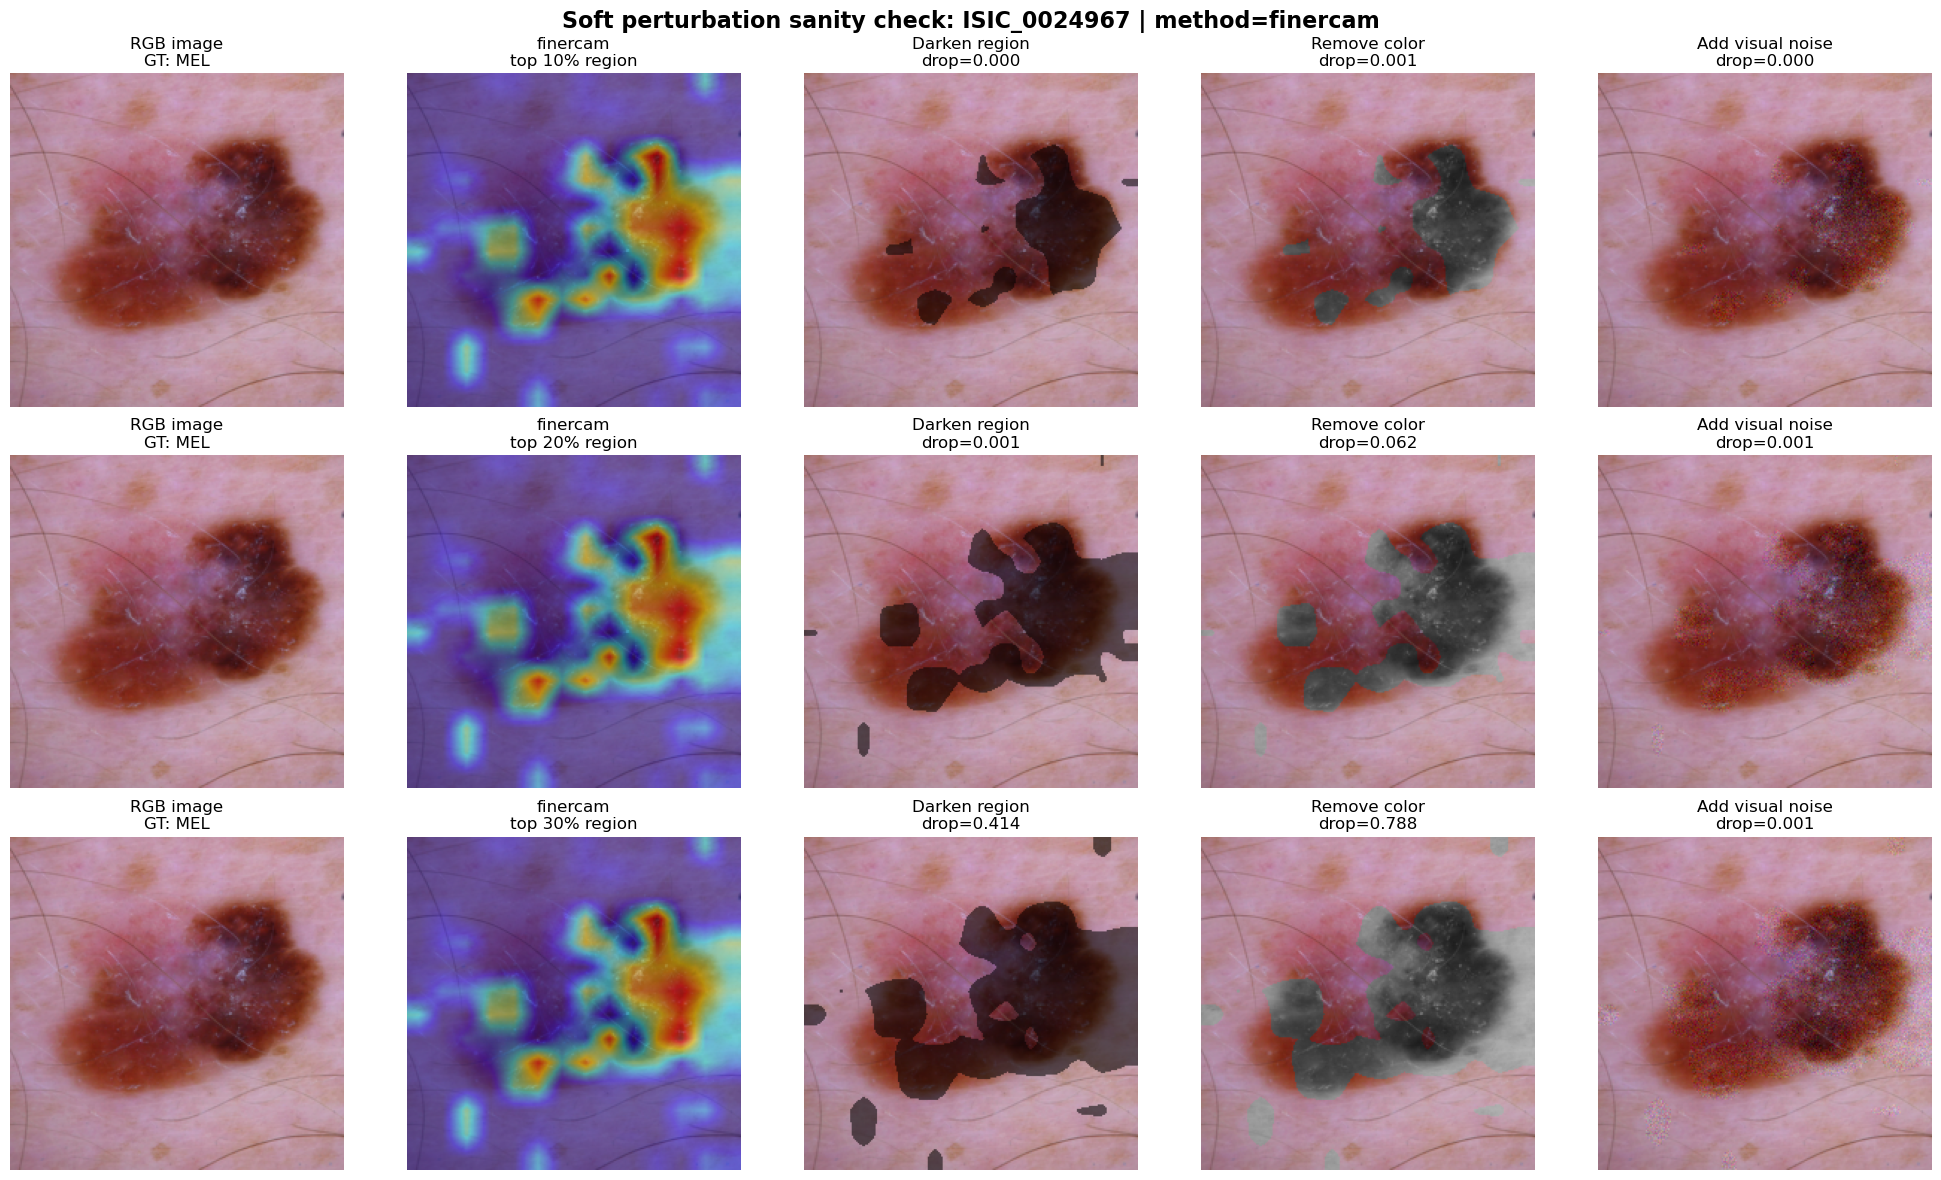

Saved: /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/soft_perturbation_ha075_block-4/visual_soft_perturbation_ISIC_0024967_finercam.png


In [14]:
# ============================================================
# Visual sanity check: same image, CAM, and soft perturbations
# ============================================================

VIS_IMAGE_ID = "ISIC_0024967"          # e.g. "ISIC_0025105"; None uses first row
# VIS_IMAGE_ID = None
VIS_METHOD = "finercam"      # gradcam_target, gradcam_diff, finercam, random_region
VIS_RATIOS = [0.1, 0.2, 0.3]
VIS_PERTURBATIONS = ["darken", "desaturate", "gaussian_noise"]


def tensor_to_rgb_np(x_norm: torch.Tensor) -> np.ndarray:
    x01 = unnormalize(x_norm.detach()).squeeze(0).permute(1, 2, 0).cpu().numpy()
    return np.clip(x01, 0.0, 1.0)


def overlay_cam_on_rgb(rgb01: np.ndarray, cam01: np.ndarray, alpha: float = 0.45) -> np.ndarray:
    cam01 = minmax_cam(cam01)
    heat = cv2.applyColorMap(np.uint8(255 * cam01), cv2.COLORMAP_JET)
    heat = cv2.cvtColor(heat, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0

    if heat.shape[:2] != rgb01.shape[:2]:
        heat = cv2.resize(heat, (rgb01.shape[1], rgb01.shape[0]), interpolation=cv2.INTER_LINEAR)

    return np.clip((1.0 - alpha) * rgb01 + alpha * heat, 0.0, 1.0)


def get_visualization_row(image_id: str | None = None):
    if image_id is None:
        return df.iloc[0]

    matches = df[df["image_id"].astype(str) == str(image_id)]
    if len(matches) == 0:
        raise ValueError(f"image_id not found in df: {image_id}")

    return matches.iloc[0]


def prepare_image_and_cam_for_visualization(row, method: str):
    image_id = str(row["image_id"])
    gt_idx = int(row["label"])

    image_path = resolve_image_path(row, IMG_DIR, image_col="image_rel_path")
    rgb = load_rgb(image_path)
    image_tensor = transform(rgb).unsqueeze(0).to(device)

    rgb_float = np.array(rgb).astype(np.float32) / 255.0
    rgb_float = cv2.resize(rgb_float, (224, 224), interpolation=cv2.INTER_LINEAR)

    cams = compute_or_load_cams(
        image_id=image_id,
        image_tensor=image_tensor,
        rgb_float=rgb_float,
        gt_idx=gt_idx,
    )

    if method == "random_region":
        cam_t = torch.zeros((1, 224, 224), dtype=torch.float32, device=device)
        cam_np = np.zeros((224, 224), dtype=np.float32)
    else:
        if method not in cams:
            raise ValueError(f"CAM method {method} not available for {image_id}. Available: {list(cams.keys())}")

        cam_np = minmax_cam(cams[method])
        cam_t = cam_to_tensor(cam_np, device=device)
        cam_t = resize_cam_to_image(cam_t, image_tensor.shape[-2:])

    with torch.no_grad():
        probs = torch.softmax(model(image_tensor), dim=1)[0].detach().cpu().numpy()

    pred_idx = int(np.argmax(probs))

    return image_id, image_tensor, tensor_to_rgb_np(image_tensor), cam_np, cam_t[0], pred_idx, probs


def plot_soft_perturbation_grid(
    image_id: str | None = VIS_IMAGE_ID,
    method: str = VIS_METHOD,
    ratios: list[float] = VIS_RATIOS,
    perturbations: list[str] = VIS_PERTURBATIONS,
):
    row = get_visualization_row(image_id)
    image_id, image_tensor, rgb01, cam_np, cam_hw, pred_idx, probs = prepare_image_and_cam_for_visualization(row, method)

    fig, axes = plt.subplots(
        len(ratios),
        2 + len(perturbations),
        figsize=(4.0 * (2 + len(perturbations)), 4.0 * len(ratios)),
    )

    if len(ratios) == 1:
        axes = np.expand_dims(axes, axis=0)

    for r_idx, ratio in enumerate(ratios):
        if method == "random_region":
            base_mask = random_mask_like(cam_hw, ratio=ratio, generator=rng)
            cam_view = base_mask.detach().cpu().numpy().astype(np.float32)
        else:
            base_mask = mask_from_cam(cam_hw, ratio=ratio)
            cam_view = cam_np

        axes[r_idx, 0].imshow(rgb01)
        axes[r_idx, 0].set_title(f"RGB image\nGT: {row['gt_label']}")
        axes[r_idx, 0].axis("off")

        axes[r_idx, 1].imshow(overlay_cam_on_rgb(rgb01, cam_view))
        axes[r_idx, 1].set_title(f"{method}\ntop {int(ratio * 100)}% region")
        axes[r_idx, 1].axis("off")

        for p_idx, perturbation_type in enumerate(perturbations):
            perturbed = perturb_image_soft(
                image_norm=image_tensor,
                mask_hw=base_mask,
                perturbation_type=perturbation_type,
                darken_factor=DARKEN_FACTOR,
                noise_std=NOISE_STD,
                generator=rng,
            )

            pert_rgb = tensor_to_rgb_np(perturbed)

            with torch.no_grad():
                pert_probs = torch.softmax(model(perturbed), dim=1)[0].detach().cpu().numpy()

            drop = float(probs[pred_idx] - pert_probs[pred_idx])

            ax = axes[r_idx, 2 + p_idx]
            ax.imshow(pert_rgb)
            ax.set_title(f"{perturb_display.get(perturbation_type, perturbation_type)}\ndrop={drop:.3f}")
            ax.axis("off")

    fig.suptitle(
        f"Soft perturbation sanity check: {image_id} | method={method}",
        fontsize=16,
        fontweight="bold",
    )

    plt.tight_layout()

    out_path = OUT_ROOT / f"visual_soft_perturbation_{image_id}_{method}.png"
    plt.savefig(out_path, dpi=220, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)


plot_soft_perturbation_grid()

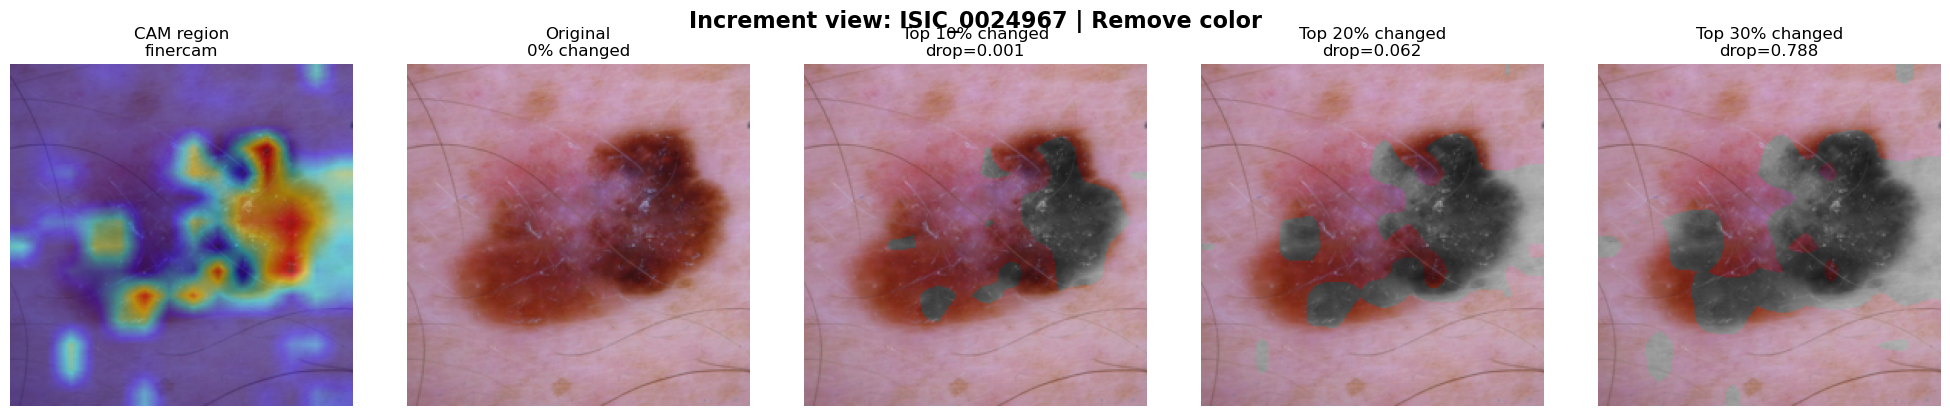

Saved: /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/soft_perturbation_ha075_block-4/visual_increment_ISIC_0024967_finercam_desaturate.png


In [15]:
# ============================================================
# Increment view up to 30%: show how the affected area grows
# ============================================================

INCREMENT_IMAGE_ID = VIS_IMAGE_ID
INCREMENT_METHOD = VIS_METHOD
INCREMENT_PERTURBATION = "desaturate"  # darken, desaturate, gaussian_noise
INCREMENT_RATIOS = [0.0, 0.1, 0.2, 0.3]


def plot_increment_view(
    image_id: str | None = INCREMENT_IMAGE_ID,
    method: str = INCREMENT_METHOD,
    perturbation_type: str = INCREMENT_PERTURBATION,
    ratios: list[float] = INCREMENT_RATIOS,
):
    row = get_visualization_row(image_id)
    image_id, image_tensor, rgb01, cam_np, cam_hw, pred_idx, probs = prepare_image_and_cam_for_visualization(row, method)

    fig, axes = plt.subplots(1, len(ratios) + 1, figsize=(4.0 * (len(ratios) + 1), 4.2))

    axes[0].imshow(overlay_cam_on_rgb(rgb01, cam_np))
    axes[0].set_title(f"CAM region\n{method}")
    axes[0].axis("off")

    for i, ratio in enumerate(ratios):
        if ratio <= 0:
            perturbed = image_tensor.clone()
            title = "Original\n0% changed"
        else:
            if method == "random_region":
                base_mask = random_mask_like(cam_hw, ratio=ratio, generator=rng)
            else:
                base_mask = mask_from_cam(cam_hw, ratio=ratio)

            perturbed = perturb_image_soft(
                image_norm=image_tensor,
                mask_hw=base_mask,
                perturbation_type=perturbation_type,
                darken_factor=DARKEN_FACTOR,
                noise_std=NOISE_STD,
                generator=rng,
            )

            with torch.no_grad():
                pert_probs = torch.softmax(model(perturbed), dim=1)[0].detach().cpu().numpy()

            drop = float(probs[pred_idx] - pert_probs[pred_idx])
            title = f"Top {int(ratio * 100)}% changed\ndrop={drop:.3f}"

        axes[i + 1].imshow(tensor_to_rgb_np(perturbed))
        axes[i + 1].set_title(title)
        axes[i + 1].axis("off")

    fig.suptitle(
        f"Increment view: {image_id} | {perturb_display.get(perturbation_type, perturbation_type)}",
        fontsize=16,
        fontweight="bold",
    )

    plt.tight_layout()

    out_path = OUT_ROOT / f"visual_increment_{image_id}_{method}_{perturbation_type}.png"
    plt.savefig(out_path, dpi=220, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)


plot_increment_view()

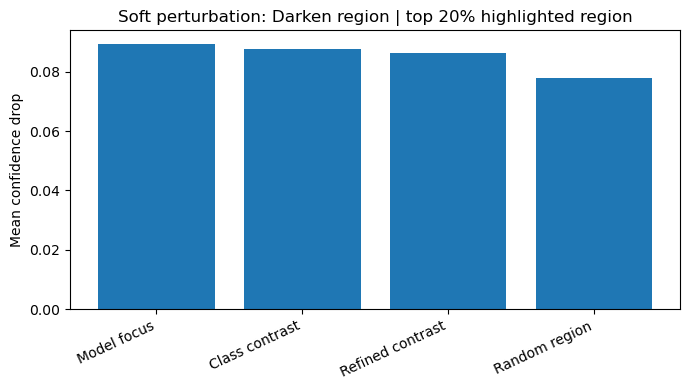

Saved: /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/soft_perturbation_ha075_block-4/plot_darken_ratio20.png


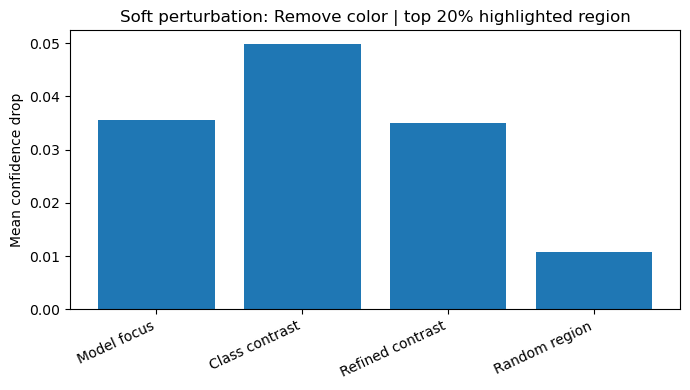

Saved: /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/soft_perturbation_ha075_block-4/plot_desaturate_ratio20.png


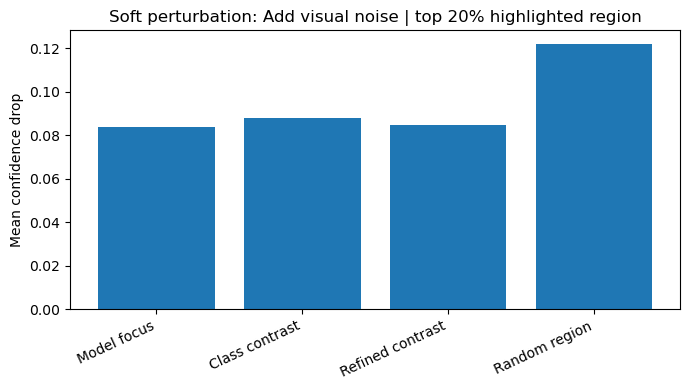

Saved: /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/soft_perturbation_ha075_block-4/plot_gaussian_noise_ratio20.png


In [12]:
def plot_summary_for_perturbation(summary_df, perturbation_type: str, ratio: float):
    sub = summary_df[
        (summary_df["perturbation_type"] == perturbation_type)
        & (np.isclose(summary_df["ratio"], ratio))
    ].copy()

    if len(sub) == 0:
        print("No data for", perturbation_type, ratio)
        return

    order = [m for m in ["gradcam_target", "gradcam_diff", "finercam", "random_region"] if m in set(sub["method"])]
    sub["method"] = pd.Categorical(sub["method"], categories=order, ordered=True)
    sub = sub.sort_values("method")

    labels = [method_display.get(m, m) for m in sub["method"].astype(str)]
    values = sub["target_drop_mean"].values

    plt.figure(figsize=(7, 4))
    plt.bar(labels, values)
    plt.ylabel("Mean confidence drop")
    plt.title(f"Soft perturbation: {perturb_display.get(perturbation_type, perturbation_type)} | top {int(ratio*100)}% highlighted region")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()

    out_path = OUT_ROOT / f"plot_{perturbation_type}_ratio{int(ratio*100)}.png"
    plt.savefig(out_path, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path)


for ptype in PERTURBATION_TYPES:
    plot_summary_for_perturbation(summary, perturbation_type=ptype, ratio=DISPLAY_RATIO)


In [23]:
by_class = (
    ok_df
    .groupby(["gt_name", "method", "perturbation_type", "ratio"], dropna=False)
    .agg(
        n=("image_id", "count"),
        target_drop_mean=("target_drop", "mean"),
        reference_drop_mean=("reference_drop", "mean"),
        finer_cam_rd_mean=("finer_cam_rd", "mean"),
        pred_changed_rate=("pred_changed", "mean"),
    )
    .reset_index()
)

by_class_path = OUT_ROOT / "soft_perturbation_summary_by_class.csv"
by_class.to_csv(by_class_path, index=False)

print("Saved:", by_class_path)
display(by_class[by_class["gt_name"] == "MEL"])

Saved: /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/soft_perturbation_ha075_block-4/soft_perturbation_summary_by_class.csv


,gt_name,method,perturbation_type,ratio,n,target_drop_mean,reference_drop_mean,finer_cam_rd_mean,pred_changed_rate
144,MEL,finercam,darken,0.1,70,0.194968,-0.064355,0.259323,0.242857
145,MEL,finercam,darken,0.2,70,0.276075,-0.083168,0.359244,0.371429
146,MEL,finercam,darken,0.3,70,0.321290,-0.094550,0.415839,0.385714
147,MEL,finercam,desaturate,0.1,70,0.217693,-0.070275,0.287968,0.271429
148,MEL,finercam,desaturate,0.2,70,0.305239,-0.095057,0.400297,0.300000
149,MEL,finercam,desaturate,0.3,70,0.383966,-0.117986,0.501952,0.457143
150,MEL,finercam,gaussian_noise,0.1,70,0.087865,-0.029229,0.117094,0.171429
151,MEL,finercam,gaussian_noise,0.2,70,0.121292,-0.040417,0.161709,0.185714
152,MEL,finercam,gaussian_noise,0.3,70,0.146517,-0.048782,0.195299,0.200000
153,MEL,gradcam_diff,darken,0.1,70,0.216997,-0.072157,0.289154,0.271429


## Interpretation guide

Use this carefully:

- **Higher confidence drop** means the perturbed region mattered more for the target class confidence.
- **Random region** is a control. If CAM-selected regions cause larger drops than random regions, the CAM is more informative than random area selection.
- **Darken** is closer to deletion, but softer than setting pixels to black in normalized space.
- **Desaturate** is useful for dermatology because color is clinically important.
- **Gaussian noise** tests local texture/visual disruption.
- This does **not** prove clinical correctness. It only tests whether the highlighted region affects the model prediction.
